In [19]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from src.features.vectorizer import (
    build_vectorizer,
    fit_transform_texts,
    fit_vectorizer,
    transform_texts,
    save_vectorizer,
    get_top_features_per_class
)
from src.utils.config import (
    PROCESSED_DATA_DIR,
    CATEGORY_TARGET,
    PRIORITY_TARGET,
    MODELS_DIR
)

sns.set_theme(style="whitegrid")

In [20]:
df = pd.read_csv(PROCESSED_DATA_DIR / "tickets_cleaned.csv")

print(f"Loaded {len(df)} cleaned tickets")
print(f"Columns: {df.columns.tolist()}")
print(f"\nSample clean text:")
print(df["clean_text"].iloc[0])

Loaded 8469 cleaned tickets
Columns: ['clean_text', 'Ticket Type', 'Ticket Priority']

Sample clean text:
im issue please assist billing zip code appreciate requested website address please double check email address ive tried troubleshooting step mentioned user manual issue persists


In [21]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y_category = df[CATEGORY_TARGET]
y_priority = df[PRIORITY_TARGET]

X_train, X_test, y_cat_train, y_cat_test = train_test_split(
    X,
    y_category,
    test_size=0.2,
    random_state=42,
    stratify=y_category
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples:     {len(X_test)}")
print(f"\nTrain category distribution:")
print(y_cat_train.value_counts())

Training samples: 6775
Test samples:     1694

Train category distribution:
Ticket Type
Refund request          1401
Technical issue         1398
Cancellation request    1356
Product inquiry         1313
Billing inquiry         1307
Name: count, dtype: int64


In [22]:
vectorizer = build_vectorizer()

# Fit ONLY on training data - never on test data
X_train_tfidf = fit_transform_texts(vectorizer, X_train)
X_test_tfidf = transform_texts(vectorizer, X_test)

print(f"\nTraining matrix:  {X_train_tfidf.shape}")
print(f"Test matrix:      {X_test_tfidf.shape}")
print(f"Vocabulary size:  {len(vectorizer.vocabulary_)}")

[2026-04-10 08:38:07] INFO — src.features.vectorizer — Building TF-IDF vectorizer with params:
[2026-04-10 08:38:07] INFO — src.features.vectorizer —   max_features: 5000
[2026-04-10 08:38:07] INFO — src.features.vectorizer —   ngram_range: (1, 2)
[2026-04-10 08:38:07] INFO — src.features.vectorizer —   min_df: 2
[2026-04-10 08:38:07] INFO — src.features.vectorizer —   max_df: 0.95
[2026-04-10 08:38:07] INFO — src.features.vectorizer —   sublinear_tf: True
[2026-04-10 08:38:07] INFO — src.features.vectorizer — Fit-transforming 6775 documents...
[2026-04-10 08:38:07] INFO — src.features.vectorizer — Vocabulary size: 5000
[2026-04-10 08:38:07] INFO — src.features.vectorizer — Feature matrix shape: (6775, 5000)
[2026-04-10 08:38:07] INFO — src.features.vectorizer — Transforming 1694 documents...
[2026-04-10 08:38:07] INFO — src.features.vectorizer — Feature matrix shape: (1694, 5000)

Training matrix:  (6775, 5000)
Test matrix:      (1694, 5000)
Vocabulary size:  5000


In [23]:
feature_names = vectorizer.get_feature_names_out()

print("First 30 features (alphabetical):")
print(feature_names[:30].tolist())

print("\nLast 30 features:")
print(feature_names[-30:].tolist())

# Find some meaningful bigrams
bigrams = [f for f in feature_names if " " in f]
print(f"\nTotal bigrams in vocabulary: {len(bigrams)}")
print(f"Sample bigrams: {bigrams[:20]}")

First 30 features (alphabetical):
['ability', 'able', 'able add', 'able answer', 'able find', 'able get', 'able help', 'able im', 'able install', 'able ive', 'able make', 'able obtain', 'able play', 'able purchase', 'able receive', 'able see', 'able sell', 'able ship', 'able take', 'able use', 'able view', 'absolutely', 'accept', 'accept payment', 'accepted', 'accepted please', 'accepting', 'access', 'access account', 'access ive']

Last 30 features:
['youll able', 'youll find', 'youll im', 'youll need', 'youll see', 'youre', 'youre buying', 'youre experiencing', 'youre going', 'youre im', 'youre interested', 'youre issue', 'youre ive', 'youre looking', 'youre paying', 'youre purchasing', 'youre right', 'youre running', 'youre selling', 'youre still', 'youre sure', 'youre using', 'youtube', 'youve', 'youve already', 'youve asked', 'youve bought', 'youve got', 'youve purchased', 'youve seen']

Total bigrams in vocabulary: 3276
Sample bigrams: ['able add', 'able answer', 'able find', 'ab

In [24]:
top_features = get_top_features_per_class(
    vectorizer,
    X_train_tfidf,
    y_cat_train,
    n=15
)

print("=== TOP 15 WORDS PER CATEGORY ===\n")
for category, words in top_features.items():
    print(f"{category}:")
    print(f"  {', '.join(words)}")
    print()

=== TOP 15 WORDS PER CATEGORY ===

Cancellation request:
  issue, im, please, assist, please assist, im issue, issue please, ive, problem, product, update, step, device, work, software

Refund request:
  issue, im, please, assist, please assist, issue please, im issue, ive, problem, product, update, data, device, software, issue persists

Technical issue:
  issue, im, please, assist, please assist, issue please, im issue, ive, problem, product, update, step, device, software, persists

Product inquiry:
  issue, im, please, assist, please assist, im issue, issue please, ive, product, problem, update, data, software, issue persists, persists

Billing inquiry:
  issue, im, please, assist, please assist, im issue, issue please, ive, problem, product, update, data, work, software, device



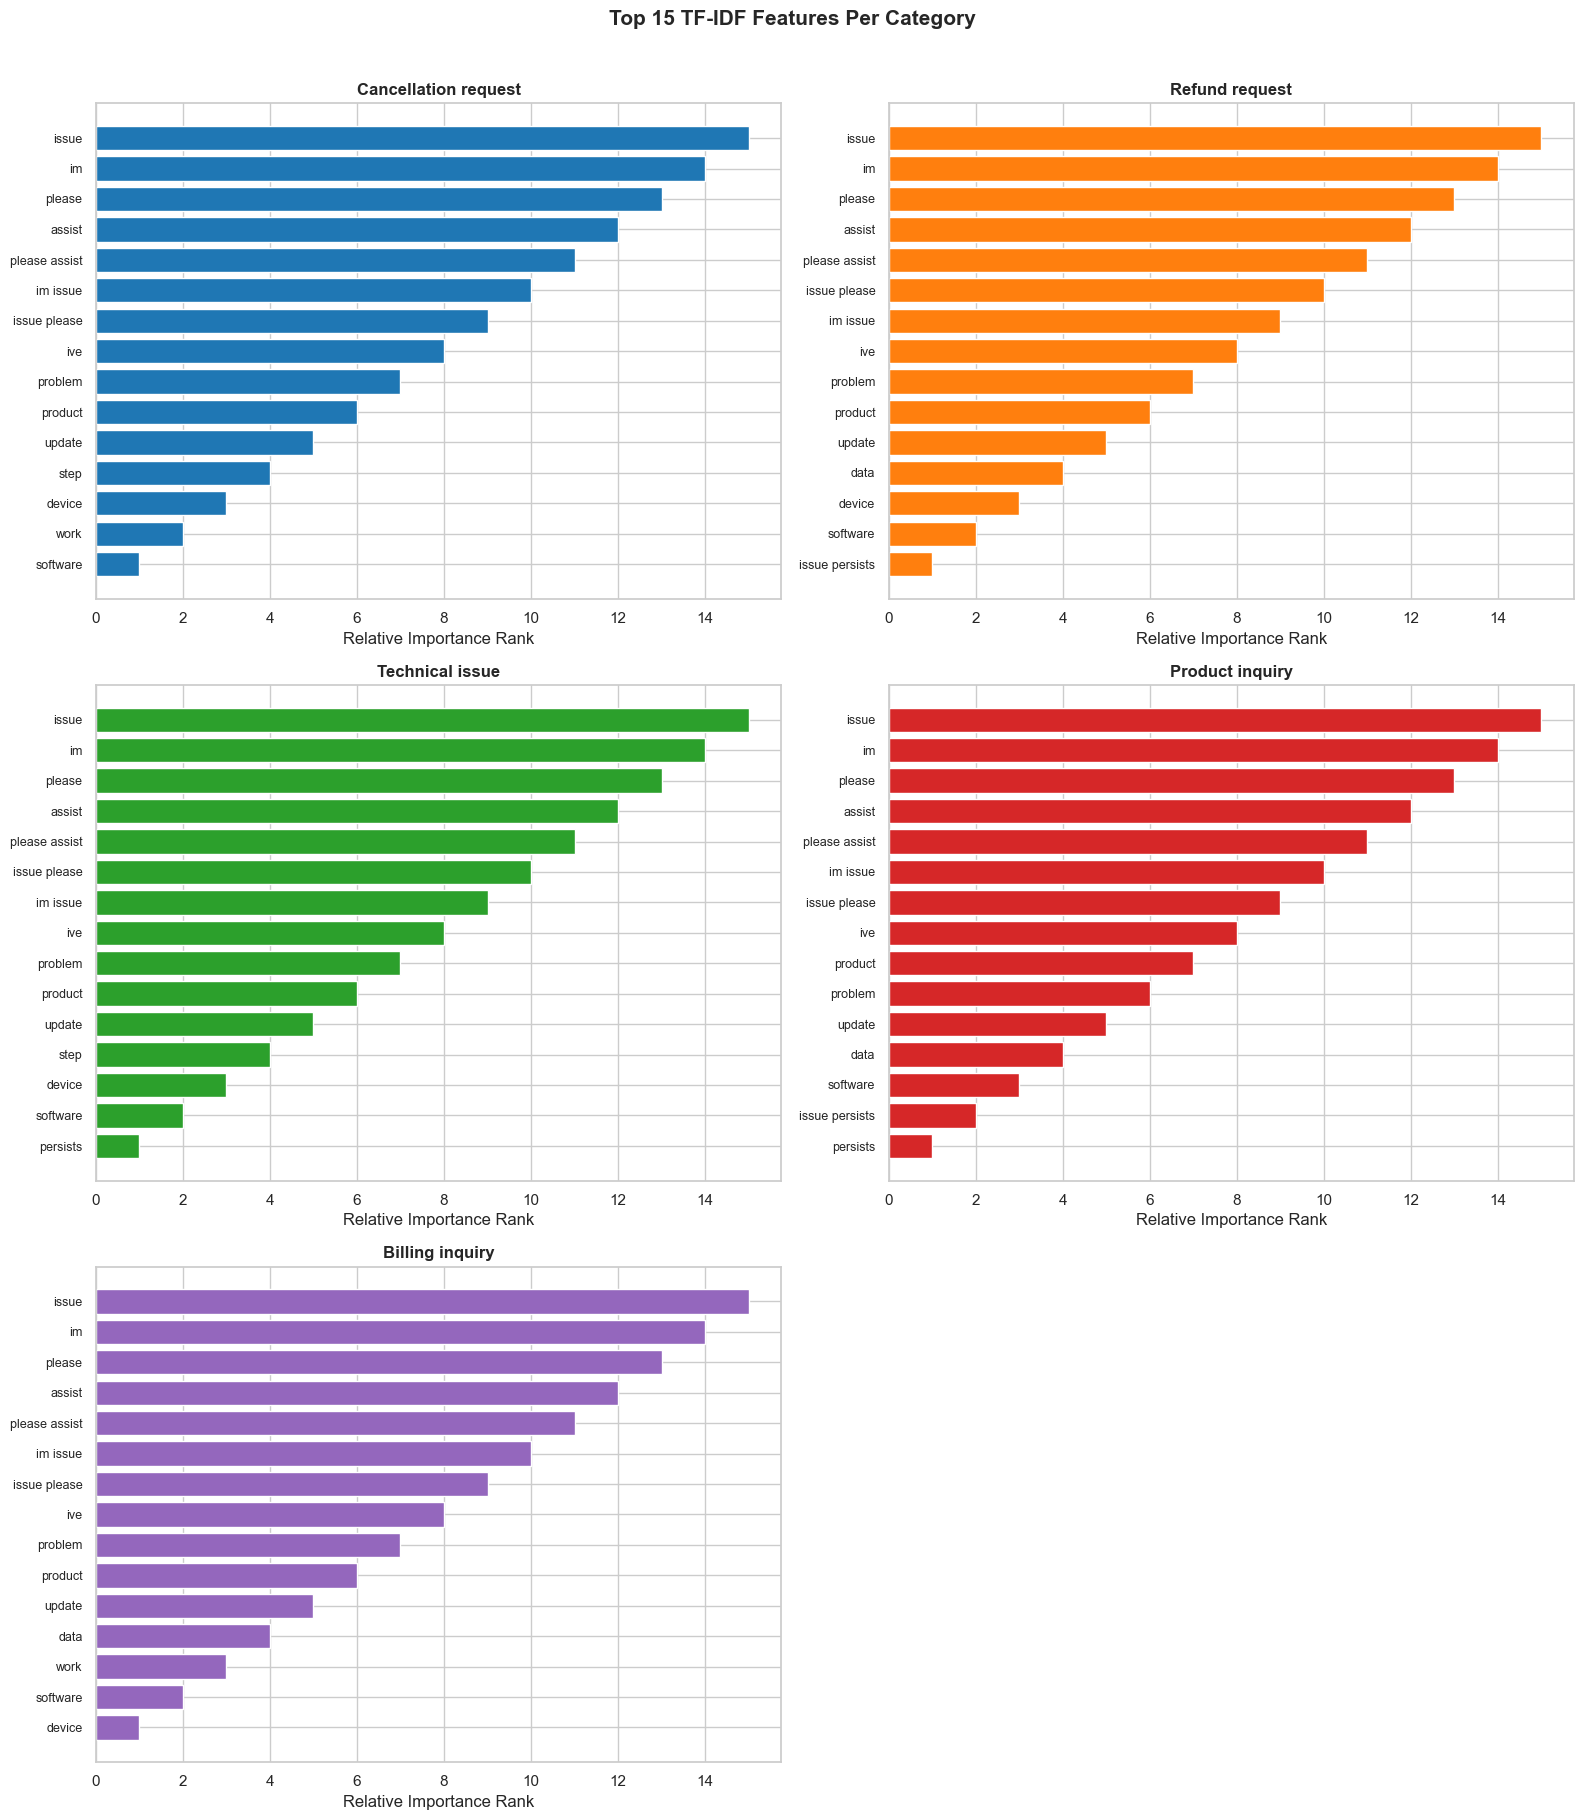

In [25]:
fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(16, 18)
)
axes = axes.flatten()

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

for idx, (category, words) in enumerate(top_features.items()):
    ax = axes[idx]
    scores = list(range(len(words), 0, -1))

    ax.barh(words[::-1], scores[::-1], color=colors[idx])
    ax.set_title(f"{category}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Relative Importance Rank")
    ax.tick_params(axis="y", labelsize=9)

# Hide the unused 6th subplot
axes[5].set_visible(False)

plt.suptitle(
    "Top 15 TF-IDF Features Per Category",
    fontsize=15,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.savefig("../outputs/figures/top_features_per_category.png", dpi=150)
plt.show()

In [26]:
total_elements = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
non_zero = X_train_tfidf.nnz
sparsity = (1 - non_zero / total_elements) * 100

print(f"Matrix shape:     {X_train_tfidf.shape}")
print(f"Total elements:   {total_elements:,}")
print(f"Non-zero elements:{non_zero:,}")
print(f"Sparsity:         {sparsity:.1f}%")

Matrix shape:     (6775, 5000)
Total elements:   33,875,000
Non-zero elements:244,236
Sparsity:         99.3%


In [27]:
from src.features.vectorizer import save_vectorizer
import joblib

# Save the fitted vectorizer
save_vectorizer(vectorizer, "tfidf_vectorizer.pkl")

# Save the train/test splits for Sprint 4 and 5
splits = {
    "X_train": X_train,
    "X_test": X_test,
    "X_train_tfidf": X_train_tfidf,
    "X_test_tfidf": X_test_tfidf,
    "y_cat_train": y_cat_train,
    "y_cat_test": y_cat_test,
    "y_priority_train": df.loc[X_train.index, PRIORITY_TARGET],
    "y_priority_test": df.loc[X_test.index, PRIORITY_TARGET],
}

joblib.dump(splits, MODELS_DIR / "train_test_splits.pkl")
print("Vectorizer and splits saved successfully")
print(f"Splits saved to: {MODELS_DIR / 'train_test_splits.pkl'}")

[2026-04-10 08:38:10] INFO — src.features.vectorizer — Vectorizer saved to E:\Future ml projects\FUTURE_ML_02\outputs\models\tfidf_vectorizer.pkl
Vectorizer and splits saved successfully
Splits saved to: E:\Future ml projects\FUTURE_ML_02\outputs\models\train_test_splits.pkl
